# Case example: 2018-03-26

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from lcc_trend_analysis.paths import get_data_paths
from lcc_trend_analysis.observations.utils import (
    get_ground_sites_gdf,
)
import cartopy.crs as ccrs
import cartopy.feature as cfeature


In [113]:
font = {"size": 7}

mpl.rc("font", **font)
figwidth = 20 / 2.56
max_figheight = 7.39

In [114]:
paths = get_data_paths()
ground_sites = get_ground_sites_gdf()
ground_sites_to_be_plotted = ["cabauw", "chilbolton", "juelich"]
ground_sites = ground_sites[ground_sites.index.isin(ground_sites_to_be_plotted)].copy()

In [115]:
date = "20170228"

In [116]:
data_file_names_alc_level1 = {
    "cabauw": f"{date}_cabauw_chm15k.nc",
    "chilbolton": f"{date}_chilbolton_cl51.nc",
    "juelich": f"{date}_juelich_chm15k.nc",
}
data_file_names_alc_level2 = {
    "cabauw": "*_cabauw_chm15k_cloud_cover.nc",
    "chilbolton": "*_chilbolton_cl51_cloud_cover.nc",
    "juelich": "*_juelich_chm15k_cloud_cover.nc",
}
datasets_alc = {
    "level1": {},
    "level2": {},
}

for site, file_name in data_file_names_alc_level1.copy().items():
    data_file_names_alc_level1[site] = paths.reference / "example" / file_name
    datasets_alc["level1"][site] = xr.open_dataset(
        data_file_names_alc_level1[site]
    )

for site, file_name in data_file_names_alc_level2.copy().items():
    data_file_names_alc_level2[site] = (paths.reference / "example").glob(file_name)
    datasets_alc["level2"][site] = xr.open_mfdataset(
        data_file_names_alc_level2[site]
    )


In [117]:
datasets_alc["level2"]["cabauw"]

<xarray.Dataset> Size: 34MB
Dimensions:                 (time: 21600, height: 1536)
Coordinates:
  * time                    (time) datetime64[ns] 173kB 2017-02-27T00:00:09 ....
  * height                  (height) float32 6kB 8.99 18.98 ... 1.534e+04
    range                   (height) float32 6kB dask.array<chunksize=(1536,), meta=np.ndarray>
Data variables:
    cloud_layer_mask        (time, height) bool 33MB dask.array<chunksize=(7200, 1536), meta=np.ndarray>
    cloud_flag              (time) bool 22kB dask.array<chunksize=(7200,), meta=np.ndarray>
    low_cloud_flag          (time) bool 22kB dask.array<chunksize=(7200,), meta=np.ndarray>
    low_cloud_and_fog_flag  (time) bool 22kB dask.array<chunksize=(7200,), meta=np.ndarray>
    cloud_base_height_asl   (time) float32 86kB dask.array<chunksize=(7200,), meta=np.ndarray>
    cloud_base_height_agl   (time) float32 86kB dask.array<chunksize=(7200,), meta=np.ndarray>
    fog_flag                (time) bool 22kB dask.array<chunksize=(7200,), meta=np.ndarray>
Attributes:
    data_source:    Unknown
    site_id:        cabauw
    date:           2017-02-27T00:00:00
    data_file:      /ritom/scratch/cscs/skarttun/data/level1/alc/l1c/cabauw/2...
    instrument:     Lufft CHM15k
    creation_date:  2026-08-06T14:32:39.384368

In [118]:
era5_level2_cloud_fractions = (
    xr.open_dataset(paths.era5_level2_clouds_hourly)["low_cloud_and_fog_cover"]
    .sel(
        time=slice(
            pd.Timestamp("2017-02-26T00:00"), pd.Timestamp("2017-03-04T00:00")
        )
    )
)
era5_level2_cloud_fractions

<xarray.DataArray 'low_cloud_and_fog_cover' (time: 145, site: 39)> Size: 23kB
[5655 values with dtype=float32]
Coordinates:
  * time        (time) datetime64[ns] 1kB 2017-02-26 ... 2017-03-04
    valid_time  (time) datetime64[ns] 1kB ...
  * site        (site) <U16 2kB 'cabauw' 'cardington' ... 'welgegund'
    latitude    (site) float64 312B ...
    longitude   (site) float64 312B ...
    step        timedelta64[ns] 8B ...
Attributes:
    units:          m
    long_name:      Height above mean sea level
    standard_name:  height_above_mean_sea_level

In [128]:
ceres_level2_cloud_fractions = (
    xr.open_dataset(
        paths.ceres_level2_clouds_raw("SYN1deg-1Hour"), engine="netcdf4"
    )["low_cloud_cover_non_obscured_adj"]
    .sel(
        time=slice(
            pd.Timestamp("2017-02-26T00:00"), pd.Timestamp("2017-03-04T00:00")
        )
    )
)


## Plotting

### ALC & ERA5 cloud fractions

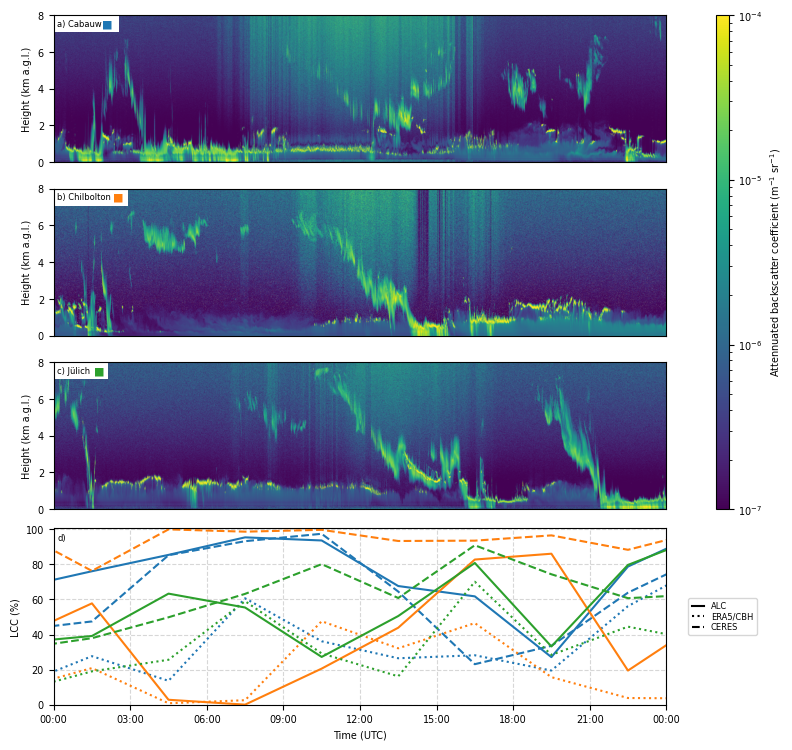

In [130]:

fig = plt.figure(figsize=(figwidth, max_figheight), layout="constrained")
gs = GridSpec(
    4, 2, figure=fig, height_ratios=[0.5, 0.5, 0.5, 0.6], hspace=0.0, width_ratios=[1, 0.02], wspace=0.00
)

site_colors = {
    "cabauw": "tab:blue",
    "chilbolton": "tab:orange",
    "juelich": "tab:green",
}

ax_sites = {}
ax_sites["cabauw"] = fig.add_subplot(gs[0, 0])
ax_sites["chilbolton"] = fig.add_subplot(gs[1, 0], sharex=ax_sites["cabauw"])
ax_sites["juelich"] = fig.add_subplot(gs[2, 0], sharex=ax_sites["cabauw"])
beta_axes = [
    ax_sites["cabauw"],
    ax_sites["chilbolton"],
    ax_sites["juelich"],
]

ax_fractions = fig.add_subplot(gs[-1, 0], sharex=ax_sites["cabauw"])
ax_cbar = fig.add_subplot(gs[0:3, 1])
ax_legend = fig.add_subplot(gs[-1, 1])
ax_legend.axis("off")

for i, site in enumerate(ground_sites_to_be_plotted):
    beta_raw = np.abs(
        datasets_alc["level1"][site]["beta_raw"].values.T
    )  # (height, time)
    time_num = mdates.date2num(datasets_alc["level1"][site]["time"].values)
    height = (
        datasets_alc["level1"][site]["height"].values
        - datasets_alc["level1"][site]["altitude"].values
    ) / 1000.0  # m -> km

    im = ax_sites[site].imshow(
        beta_raw,
        origin="lower",
        aspect="auto",
        extent=[time_num[0], time_num[-1], height[0], height[-1]],
        norm=mcolors.LogNorm(vmin=1e-7, vmax=1e-4),
        cmap="viridis",
    )

    cloud_mask = (
        datasets_alc["level2"][site]["cloud_layer_mask"]
        .where((height < 2), other=False)
        .values
    )  # (time, height), bool
    t_idx, h_idx = np.where(cloud_mask)

    """
    ax_sites[site].scatter(
        time_num[t_idx],
        height[h_idx],
        c="red",
        s=0.01,
        alpha=1.0,
        marker="o",
        linewidths=0,
    )
    """
    
    """
    ax_sites[site].imshow(
        cloud_mask.T,
        origin="lower",
        aspect="auto",
        extent=[time_num[0], time_num[-1], height[0], height[-1]],
        cmap=mcolors.ListedColormap(["none", "red"]),
        alpha=1.0,
    )
    """
            
    letter = chr(97 + i)
    label = f"{letter}) {ground_sites.loc[site, 'humanReadableName']} {" "*4}"

    site_label = ax_sites[site].text(
        0.006,
        0.975,
        label,
        color="k",
        transform=ax_sites[site].transAxes,
        va="top",
        ha="left",
        fontsize=6,
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 1.0,
            "pad": 3.0,
        },
        zorder=1,
    )

    fig.canvas.draw()  # ensure text extents are available
    renderer = fig.canvas.get_renderer()

    # get the rendered width of the label and convert its right edge to axes coords
    bbox = site_label.get_window_extent(renderer=renderer)
    x_right_axes = ax_sites[site].transAxes.inverted().transform((bbox.x1, bbox.y1))[0]

    ax_sites[site].text(
        x_right_axes - 0.01,  # small gap after label
        0.91,
        "■",
        color=site_colors[site],
        transform=ax_sites[site].transAxes,
        va="bottom",
        ha="left",
        fontsize=8,
        zorder=2,
    )
    # ax_sites[site].axhline(0.15, color="red", linestyle="--", linewidth=1)

    lcc_fractional = datasets_alc["level2"][site]["low_cloud_flag"]
    lcc_fractional["time"] = datasets_alc["level2"][site][
        "time"
    ]
    lcc_resampled = lcc_fractional.resample(time="3h", label="left").mean()
    lcc_resampled["time"] = lcc_resampled["time"] + pd.Timedelta("1h30min")
    ax_fractions.plot(
        lcc_resampled["time"],
        lcc_resampled.values*100,
        label=site.capitalize(),
        c=site_colors[site],
        linewidth=1.5,
    )
    era5_site = era5_level2_cloud_fractions.sel(site=site).resample(time="3h", label="left").mean()
    era5_site["time"] = era5_site["time"] + pd.Timedelta("1h30min")

    ax_fractions.plot(
        era5_site["time"],
        era5_site.values*100,
        c=site_colors[site],
        linewidth=1.5,
        linestyle=":",
    )
    
    ceres_site = ceres_level2_cloud_fractions.sel(site=site).resample(time="3h", label="left").mean()
    ceres_site["time"] = ceres_site["time"] + pd.Timedelta("1h30min")
    ax_fractions.plot(
        ceres_site["time"],
        ceres_site.values*100,
        c=site_colors[site],
        linewidth=1.5,
        linestyle="--",
    )
    
    if i == 0:
        fig.colorbar(
            im,
            cax=ax_cbar,
            orientation="vertical",
            label=r"Attennuated backscatter coefficient (m$^{-1}$ sr$^{-1}$)",
        )

timeseries_axes = [*beta_axes, ax_fractions]
for ax in timeseries_axes[:-1]:
    ax.xaxis.set_visible(False)
    ax.set_ylabel("Height (km a.g.l.)")
    ax.set_ylim(0, top=8)

letter = chr(97 + i + 1)
timeseries_axes[-1].text(
    0.006,
    0.975,
    f"{letter})",
    color="k",
    transform=timeseries_axes[-1].transAxes,
    va="top",
    ha="left",
    fontsize=6,
    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 1.0, "pad": 3.0},
    zorder=1,
)
timeseries_axes[-1].set_xlabel("Time (UTC)")
timeseries_axes[-1].xaxis_date()
timeseries_axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=3))
timeseries_axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax_fractions.set_ylabel(r"LCC (%)")
timeseries_axes[-1].set_ylim(-0.05, 100.5)
timeseries_axes[-1].set_xlim(round(time_num[0]), round(time_num[-1]))
timeseries_axes[-1].grid(
    True, which="both", axis="both", linestyle="--", alpha=0.5
)

# Add legend for the fractions
linestyles = {"ALC": "-", "ERA5/CBH": ":", "CERES": "--"}
ax_legend.legend(
    [ax_fractions.plot([], [], c="k", linestyle=linestyles[source])[0] for source in linestyles.keys()],
    [source for source in linestyles.keys()],
    loc="center",
    ncol=1,
    frameon=True,
    fontsize=6,
    handlelength=1.5,
    handleheight=0.5,
    labelspacing=0.2,
)
fig.savefig(paths.results / "case_example" / "case_example_alc_era5_ceres.pdf", dpi=300, bbox_inches="tight")